# Load CSVs referenced in metadata (Metadatos_diccionario.xlsx)

This notebook performs the following steps:
1. Reads all sheets from `data/Metadatos_diccionario.xlsx`.
2. Displays each sheet head and columns so you can inspect metadata.
3. Detects rows that reference CSV files using heuristics (columns named like `formato`, `tipo`, or any cell containing `.csv`).
4. Opens each referenced CSV (paths resolved relative to the repository `data/` folder), loads into a pandas DataFrame, standardizes/renames a detected 'name' column to `name`, and attempts to parse date-like columns.

Assumptions: If the metadata sheet doesn't use consistent column names, the notebook will try a set of common column-name candidates to find the CSV filename and the 'name' column. If a referenced CSV path is relative, it is resolved under `data/`.

Run the cells sequentially. If the Excel file uses unusual column names, inspect the printed sheet outputs and adapt the heuristics below.

In [1]:
# Standard imports
import pandas as pd
from pathlib import Path
import re
from IPython.display import display

# Convenience
ROOT = Path('c:/Users/ASUS/Documents/bcol_prueba_2025') # assume notebook is run from repository root; adjust if needed
DATA_DIR = ROOT / 'data'
EXCEL_PATH = DATA_DIR / 'Metadatos_diccionario.xlsx'

print('Repository root:', ROOT)
print('Data dir:', DATA_DIR)
print('Looking for Excel metadata at:', EXCEL_PATH)

Repository root: c:\Users\ASUS\Documents\bcol_prueba_2025
Data dir: c:\Users\ASUS\Documents\bcol_prueba_2025\data
Looking for Excel metadata at: c:\Users\ASUS\Documents\bcol_prueba_2025\data\Metadatos_diccionario.xlsx


In [2]:
# Load the Excel file and show sheet names
if not EXCEL_PATH.exists():
    raise FileNotFoundError(f'Metadata Excel not found at {EXCEL_PATH}. Please verify path.')

xls = pd.ExcelFile(EXCEL_PATH)
sheets = xls.sheet_names
print('Found sheets:', sheets)

PANDAS_TYPE_MAP = {
    'bigint': 'Int64',   # nullable 64-bit integer
    'int':    'Int64',   # nullable integer
    'tinyint':'Int8',    # small nullable integer
    'string': 'string'   # pandas StringDtype (nullable)
}

# Display each sheet's first rows and columns for inspection
sheets_preview = {}
for name in sheets:
    try:
        df = xls.parse(name)
        if "Tipo" in df.columns:
            df = df.rename(columns={"Tipo": "type", "Nombre": "name"})
        if "name " in df.columns:
            df = df.rename(columns={"name ": "name"})
        df['type_pandas'] = df['type'].map(lambda t: PANDAS_TYPE_MAP.get(t.lower(), 'object') if isinstance(t, str) else 'object')
    except Exception as e:
        print(f'Could not parse sheet {name}: {e}')
        continue
    sheets_preview[name] = df.head(5)
    print('--- Sheet:', name, '---')
    print('Shape:', df.shape)
    print('Columns:', list(df.columns))
    display(df.head(5))

Found sheets: ['pcac_mac_gpi_clientes', 'pcac_mac_gpi_ecas', 'pcac_mac_gpi_tenencia_prod', 'pcac_planta_comercial2', 'pcac_encuesta', 'pcac_capacidad_gerentes', 'pcac_oportunidades_comer']
--- Sheet: pcac_mac_gpi_clientes ---
Shape: (38, 4)
Columns: ['name', 'type', 'comment', 'type_pandas']


,name,type,comment,type_pandas
0,num_doc_cli,bigint,Número de documento Cliente Preferencial,Int64
1,cod_tipo_doc_cli,tinyint,Código del tipo de documento Cliente Preferencial,Int8
2,num_doc_cli_dv,bigint,Número de documento Cliente Preferencial con d...,Int64
3,cli_val,tinyint,Si es cliente Valores,Int8
4,cli_pan,tinyint,Si es cliente Panamá,Int8


--- Sheet: pcac_mac_gpi_ecas ---
Shape: (23, 4)
Columns: ['name', 'type', 'comment', 'type_pandas']


,name,type,comment,type_pandas
0,num_doc_gte_inv,bigint,Documento Gerente de Inversión,Int64
1,cod_gte_inv,bigint,Codigo del Gerente de Inversión,Int64
2,nombre_gte_inv,string,Nombre del Gerente,string
3,num_doc_ejec_bco,bigint,Documento del Ejecutivo del Gerente,Int64
4,cod_ejec_bco,bigint,Codigo del ejecutivo,Int64


--- Sheet: pcac_mac_gpi_tenencia_prod ---
Shape: (7, 4)
Columns: ['name', 'type', 'Unnamed: 2', 'type_pandas']


...

,name,type,type_pandas
0,nombre_comercial,string,string
1,cedula_comercial,bigint,Int64
2,codigo_de_vendedor,bigint,Int64
3,cod_producto,bigint,Int64
4,producto,string,string


--- Sheet: pcac_capacidad_gerentes ---
Shape: (5, 4)
Columns: ['name', 'type', 'comment', 'type_pandas']


,name,type,comment,type_pandas
0,cod_gte_inv,bigint,Código del gerente de inversión,Int64
1,cod_region_gte_inv,tinyint,código que representa la región donde se encue...,Int8
2,sistematica_anual,bigint,código general del proceso (obviar),Int64
3,tiempo_instrum_resta,bigint,tiempo general estimado de instrumentación de...,Int64
4,tiempo_restante,bigint,tiempo disponible para actividades comerciales...,Int64


--- Sheet: pcac_oportunidades_comer ---
Shape: (7, 4)
Columns: ['name', 'type', 'Descripción', 'type_pandas']


,name,type,Descripción,type_pandas
0,num_doc_cli,bigint,Número de documento del cliente,Int64
1,cod_tipo_doc_cli,int,tipo de documento del cliente,Int64
2,id_oport,string,identificador de la oportunidad comercial,string
3,cat_oport,string,categoria de la oportunidad comercial,string
4,nombre_activo_oport,string,Nombre de la Oportunidad Comercial,string


In [3]:
dict_dataframes = {}

for name_table in sheets:
    try:
        types_table = zip(sheets_preview[name_table]['name'].to_list(),
            sheets_preview[name_table]['type_pandas'].to_list())
        path_table = DATA_DIR / (name_table + '.csv')
        dict_dataframes[name_table] = pd.read_csv(path_table, dtype=dict(types_table))
    except Exception as e:
        print(f'Could not load CSV for table {name_table}: {e}')


In [4]:
dict_dataframes.keys()

dict_keys(['pcac_mac_gpi_clientes', 'pcac_mac_gpi_ecas', 'pcac_mac_gpi_tenencia_prod', 'pcac_planta_comercial2', 'pcac_encuesta', 'pcac_capacidad_gerentes', 'pcac_oportunidades_comer'])

In [5]:
dict_dataframes['pcac_oportunidades_comer'].head()

,num_doc_cli,cod_tipo_doc_cli,id_oport,cat_oport,nombre_activo_oport,cod_producto,producto
0,1213305917074214330,1,T-RF-C-5,Renta Fija,Compra TES TF 27,23,tiene_rta_fija_valores
1,5494563287741999667,1,F-RV-C-8,Renta Variable,Compra FIC Renta Alta Convicción,16,tiene_rta_alta_conviccion
2,6157656402768940709,1,F-RF-C-8,Renta Fija,Participar en la emisión Bono Serfinanza,23,tiene_rta_fija_valores
3,2357349050148098513,1,F-RV-C-8,Renta Variable,Compra FIC Renta Alta Convicción,16,tiene_rta_alta_conviccion
4,8293359715880194961,1,F-RF-C-6,Renta Fija,Compra FIC Renta Fija Plazo,23,tiene_rta_fija_valores


In [6]:
print("Inicio de la base de clientes")
print(dict_dataframes['pcac_mac_gpi_clientes'].shape)
dict_dataframes['pcac_mac_gpi_clientes'][['marca_mac_inv','score_modelo']].head()

Inicio de la base de clientes
(34145, 38)


,marca_mac_inv,score_modelo
0,B,0.19
1,B,0.06
2,B,0.12
3,B,0.09
4,C,0.03


## Pruebas de calculo del tiempo del cliente

### Calculo del promedio de tiempo por producto

In [7]:
promedio_producto = dict_dataframes['pcac_encuesta'].groupby('cod_producto').agg({'total_promedio_tiempo_min_x_actividad':'mean', 'total_promedio_volumen_por_semana':'mean'}).reset_index()
promedio_producto.head()

,cod_producto,total_promedio_tiempo_min_x_actividad,total_promedio_volumen_por_semana
0,1,44.146341,0.1
1,4,28.292683,4.0
2,5,28.292683,4.0
3,6,28.292683,4.0
4,7,28.292683,4.0


In [31]:
promedio_producto.shape

(30, 3)

In [32]:
dict_dataframes['pcac_oportunidades_comer'].shape

(247863, 7)

In [8]:
oportunidades_agrupadas = dict_dataframes['pcac_oportunidades_comer'].groupby(['num_doc_cli', 'cod_producto']).size().reset_index(name='count_oportunidades')
oportunidades_agrupadas.head(9)

,num_doc_cli,cod_producto,count_oportunidades
0,771500524365043,23,2
1,904908247262611,12,1
2,904908247262611,16,1
3,904908247262611,23,2
4,904908247262611,27,1
5,904908247262611,36,1
6,1368073034339205,0,1
7,1368073034339205,14,1
8,1368073034339205,16,1


In [30]:
oportunidades_agrupadas.shape

(139608, 3)

In [9]:
cruce_cliente_tiempo = oportunidades_agrupadas.merge(promedio_producto[['cod_producto', 'total_promedio_tiempo_min_x_actividad', 'total_promedio_volumen_por_semana']], on='cod_producto', how='left')
cruce_cliente_tiempo.head()

,num_doc_cli,cod_producto,count_oportunidades,total_promedio_tiempo_min_x_actividad,total_promedio_volumen_por_semana
0,771500524365043,23,2,23.121951,1.6
1,904908247262611,12,1,28.292683,4.0
2,904908247262611,16,1,28.292683,4.0
3,904908247262611,23,2,23.121951,1.6
4,904908247262611,27,1,21.585366,1.2


In [29]:
cruce_cliente_tiempo.shape

(139608, 5)

In [10]:
agrupamiento_x_tiempo = cruce_cliente_tiempo.groupby(['num_doc_cli','count_oportunidades']).agg({'total_promedio_tiempo_min_x_actividad':'sum', 'total_promedio_volumen_por_semana':'sum'}).reset_index()
agrupamiento_x_tiempo.head()

,num_doc_cli,count_oportunidades,total_promedio_tiempo_min_x_actividad,total_promedio_volumen_por_semana
0,771500524365043,2,23.121951,1.6
1,904908247262611,1,92.317073,10.8
2,904908247262611,2,23.121951,1.6
3,1368073034339205,1,56.585366,8.0
4,1368073034339205,2,23.121951,1.6


In [11]:
# Calculo del tiempo final del cliente
# agrupamiento_x_tiempo['minutos_year'] = agrupamiento_x_tiempo['total_promedio_tiempo_min_x_actividad'] * agrupamiento_x_tiempo['count_oportunidades'] * agrupamiento_x_tiempo['total_promedio_volumen_por_semana'] * 52
agrupamiento_x_tiempo['minutos'] = agrupamiento_x_tiempo['total_promedio_tiempo_min_x_actividad'] * agrupamiento_x_tiempo['count_oportunidades']

In [37]:
agrupamiento_x_tiempo_final = agrupamiento_x_tiempo.groupby('num_doc_cli').agg({'minutos':'sum'}).reset_index()
agrupamiento_x_tiempo_final.head()

,num_doc_cli,minutos
0,771500524365043,46.243902
1,904908247262611,138.560976
2,1368073034339205,102.829268
3,1463012463827735,46.243902
4,1507648131004221,210.829268


In [38]:
agrupamiento_x_tiempo_final.shape

(32394, 2)

## Tiempo del gerente

In [39]:
tiempo_minimo_gerentes = dict_dataframes['pcac_capacidad_gerentes'][['tiempo_restante']].min()
tiempo_maximo_gerentes = dict_dataframes['pcac_capacidad_gerentes'][['tiempo_restante']].max()

print(f'Tiempo minimo restante de gerentes: {tiempo_minimo_gerentes}')
print(f'Tiempo maximo restante de gerentes: {tiempo_maximo_gerentes}') 


Tiempo minimo restante de gerentes: tiempo_restante    75930
dtype: Int64
Tiempo maximo restante de gerentes: tiempo_restante    75930
dtype: Int64


In [40]:
# El tiempo esta en minutos, se convierte a semanas
tiempo_g_minutos = 75930
tiempo_g_semanas = tiempo_g_minutos / (52*60)
tiempo_g_semanas

24.33653846153846

### Comparemos con los valores reales

In [41]:
add_time = dict_dataframes['pcac_mac_gpi_clientes'].merge(agrupamiento_x_tiempo_final[['num_doc_cli','minutos']], on='num_doc_cli', how='left')

In [44]:
print(add_time.shape)
add_time.head()

(34145, 39)


,num_doc_cli,cod_tipo_doc_cli,num_doc_cli_dv,cli_val,cli_pan,cli_per,num_doc_gte_inv,nombre_gte_inv,cod_gte_inv,ciudad_gte_inv,...,cod_calif_riesgo_bco,perfil_riesgo_val,riesgo_sarlaft_bco,marca_mac_inv2,score_modelo2,banca_gte_cons,cliente_nuevo,marca_mac_inv,score_modelo,minutos
0,792948952420445876,1,792948952420445876,1,0,0,1872056861363575577,3684e207099dc9903324,8648915042775491028,SANTA MARTA,...,G1,MODERADO,RIESGO MUY BAJO,B,0.19,PREFERENCIAL,0,B,0.19,131.121951
1,3972597626226801159,1,3972597626226801159,1,0,0,1872056861363575577,3684e207099dc9903324,8648915042775491028,SANTA MARTA,...,G1,MODERADO,RIESGO BAJO,B,0.06,PREFERENCIAL,0,B,0.06,60.390244
2,2753978090031414171,1,2753978090031414171,1,0,0,1872056861363575577,3684e207099dc9903324,8648915042775491028,SANTA MARTA,...,G1,CONSERVADOR,RIESGO MUY BAJO,B,0.12,PREFERENCIAL,0,B,0.12,79.707317
3,289615200991922439,1,289615200991922439,1,0,0,1872056861363575577,3684e207099dc9903324,8648915042775491028,SANTA MARTA,...,G1,AGRESIVO,RIESGO MUY BAJO,B,0.09,PREFERENCIAL,0,B,0.09,213.097561
4,3537185204720284636,1,3537185204720284636,1,0,0,1872056861363575577,3684e207099dc9903324,8648915042775491028,SANTA MARTA,...,G1,SIN DEFINIR,RIESGO MUY BAJO,C,0.03,PREFERENCIAL,0,C,0.03,125.951220


In [45]:
tiempo_gerente = add_time.groupby('cod_gte_inv').agg({'minutos':'sum'}).reset_index()

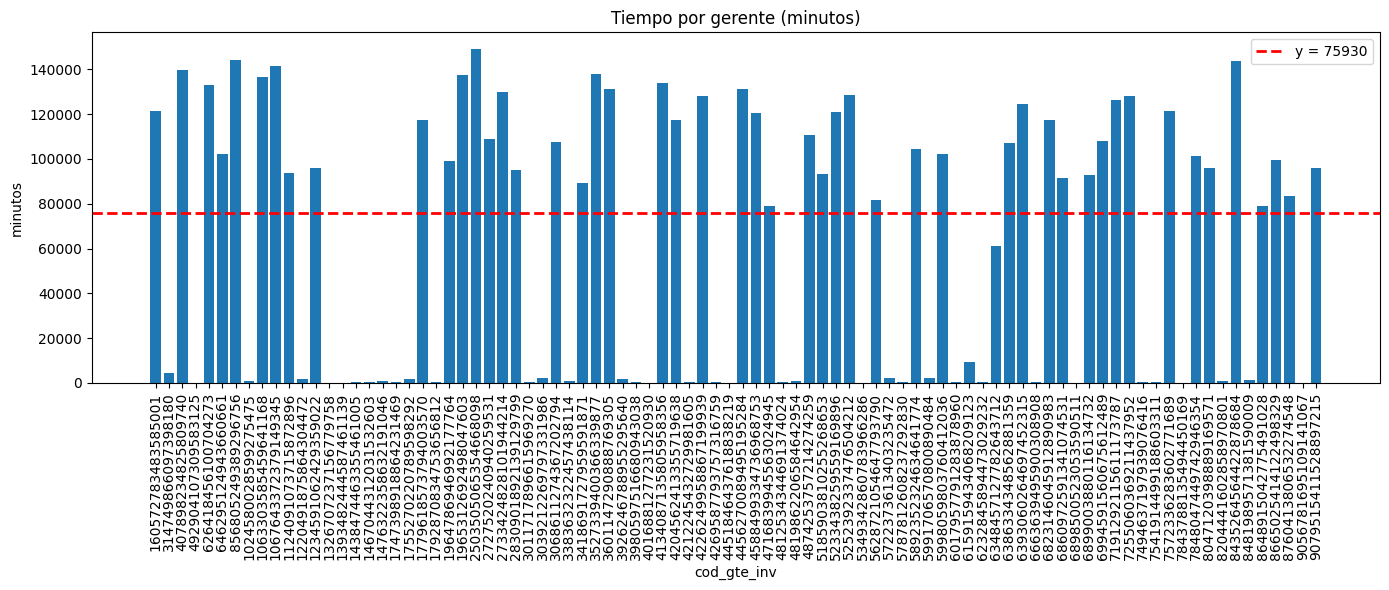

In [46]:
import matplotlib.pyplot as plt

df = tiempo_gerente.copy()
x = df['cod_gte_inv'].astype(str)
y = df['minutos']

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x, y, color='C0')
ax.axhline(75930, color='red', linestyle='--', linewidth=2, label='y = 75930')
ax.set_xlabel('cod_gte_inv')
ax.set_ylabel('minutos')
ax.set_title('Tiempo por gerente (minutos)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
add_time.columns

Index(['num_doc_cli', 'cod_tipo_doc_cli', 'num_doc_cli_dv', 'cli_val',
       'cli_pan', 'cli_per', 'num_doc_gte_inv', 'nombre_gte_inv',
       'cod_gte_inv', 'ciudad_gte_inv', 'region_gte_inv', 'cod_region_gte_inv',
       'nombre_gte_regional_inv', 'estado_gte_inv', 'cod_ejec_bco',
       'nombre_ejec_bco', 'cod_suc_ejec_bco', 'cod_dane', 'ciudad',
       'region_ejec_bco_1', 'cod_region_ejec_bco_1', 'region_ejec_bco',
       'cod_region_ejec_bco', 'gerenciamiento_bco', 'cod_ciiu', 'ciiu',
       'segm_cli', 'subsegm_cli', 'marca_lista_ctrl', 'cod_calif_riesgo_bco',
       'perfil_riesgo_val', 'riesgo_sarlaft_bco', 'marca_mac_inv2',
       'score_modelo2', 'banca_gte_cons', 'cliente_nuevo', 'marca_mac_inv',
       'score_modelo', 'minutos'],
      dtype='object')

In [47]:
df_time_client = add_time[
    ['num_doc_cli', 'cod_tipo_doc_cli','cod_ejec_bco',
     'region_ejec_bco_1', 'cod_region_ejec_bco_1', 'region_ejec_bco',
    'cod_region_ejec_bco','cod_gte_inv','ciudad_gte_inv', 'region_gte_inv', 
     'cod_region_gte_inv','marca_mac_inv', 'score_modelo','minutos']].copy()

In [48]:
df_time_client.shape

(34145, 14)

In [49]:
df_time_client.shape
df_time_client.head()

,num_doc_cli,cod_tipo_doc_cli,cod_ejec_bco,region_ejec_bco_1,cod_region_ejec_bco_1,region_ejec_bco,cod_region_ejec_bco,cod_gte_inv,ciudad_gte_inv,region_gte_inv,cod_region_gte_inv,marca_mac_inv,score_modelo,minutos
0,792948952420445876,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.19,131.121951
1,3972597626226801159,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.06,60.390244
2,2753978090031414171,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.12,79.707317
3,289615200991922439,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,B,0.09,213.097561
4,3537185204720284636,1,5011585778571550166,CARIBE,3.0,CARIBE,3,8648915042775491028,SANTA MARTA,CARIBE,3,C,0.03,125.951220


In [50]:
df_time_client.to_csv(DATA_DIR / 'pcac_clientes_tiempo_estimado.csv', index=False)

In [51]:
df_time_client['minutos'].isnull().sum()

np.int64(1751)